In [1]:
import netCDF4
from netCDF4 import Dataset, num2date
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import wrf
import pandas as pd
import tropycal.tracks as tracks
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [12]:

runnamelist = ['control', 'diurnal', 'c_imp', 'd_imp','nocrf', 'nocrf_imp']
#Determine masking variables
track_file_control = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin3000track_rvor.nc"
track_file_diurnal = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin_d3000track_rvor.nc"
track_file_ctrlimp = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0409253000track_rvor.nc"
track_file_cimp2 = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0714253000track_rvor.nc"
track_file_diurnalimp = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erindimp0409253000track_rvor.nc"
track_file_dimp2 = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erindiurnalimp0808253000track_rvor.nc"
track_file_nocrf = "/home/colinwelty/wrf-stuff/erinproc/erin3000crftrack_rvor.nc"
track_file_nocrfimp = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erincrfimp0526253000track_rvor.nc"
track_file_nocrfimp2 = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erincrfimp0731253000track_rvor.nc"

track_files = [track_file_control, track_file_diurnal, track_file_nocrf, track_file_ctrlimp, track_file_diurnalimp,  track_file_nocrfimp]

In [3]:
#Import Dataset for Best Track Data
url = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2022-042723.txt"
basin = tracks.TrackDataset(basin='north_atlantic', atlantic_url=url)
storm = basin.get_storm(('erin',2007))
storm = storm.to_xarray()
slats = storm.variables['lat'][:]
slons = storm.variables['lon'][:]

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (2.4 seconds)


In [36]:
#Only run if you want two tracks
runnamelist = ['control', 'diurnal']
track_files = [track_file_control, track_file_diurnal]

In [8]:
runnamelist = ['control', 'c_imp', 'c_imp2', 'd_imp', 'd_imp2', 'nocrf_imp', 'nocrf_imp2']
track_files = [track_file_control, track_file_ctrlimp, track_file_cimp2, track_file_diurnalimp, track_file_dimp2, track_file_nocrfimp, track_file_nocrfimp2]

In [6]:
runnamelist = ['d_imp2']
track_files = [track_file_dimp2]

In [16]:
runnamelist = ['control', 'c_imp1', 'c_imp2', 'diurnal','d_imp1', 'd_imp2']
track_files = [track_file_control, track_file_ctrlimp, track_file_cimp2, track_file_diurnal, track_file_diurnalimp, track_file_nocrf]

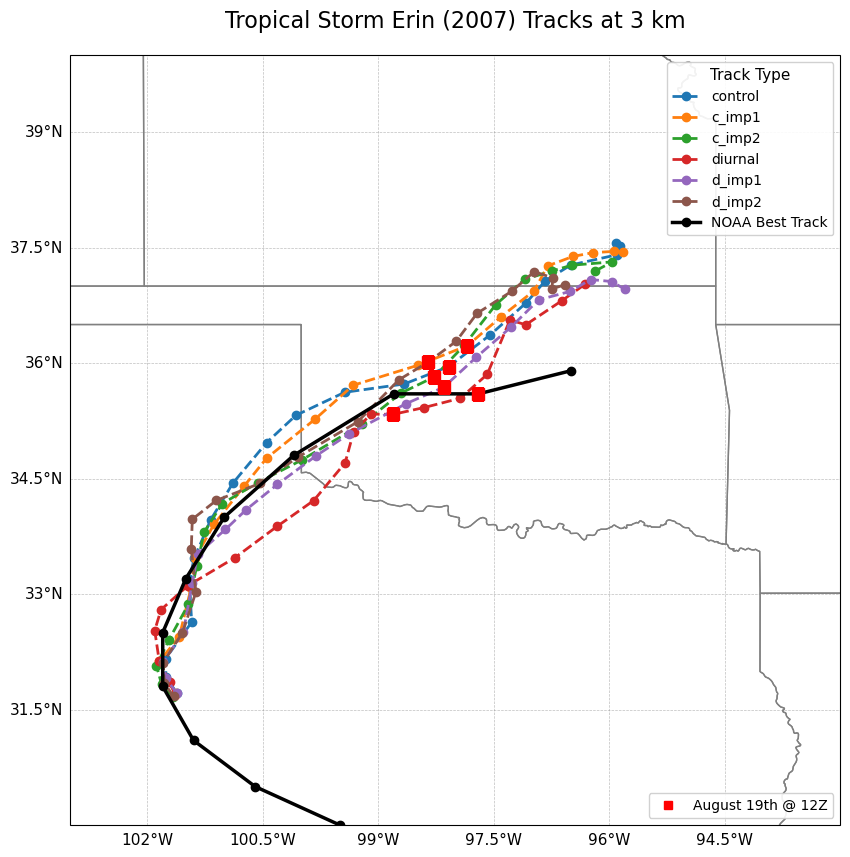

In [17]:

# Constants
highlight_index_sim = 39  # Aug 19 @ 12Z from start of sim
target_time_str = '2007-08-19T12:00:00'
target_time = np.datetime64(target_time_str)

# Set color cycle for model tracks
colors = plt.get_cmap('tab10').colors

# Setup storage
track_lats = []
track_lons = []
highlight_points_sim = []

# Gather simulation track points
for track_file in track_files:
    track_data = Dataset(track_file)
    lats = track_data.variables['clat'][:]
    lons = track_data.variables['clon'][:]

    track_lats.append(lats)
    track_lons.append(lons)

    # Get 12Z Aug 19 point if it exists
    if len(lats) > highlight_index_sim:
        highlight_points_sim.append((lons[highlight_index_sim], lats[highlight_index_sim]))
    else:
        highlight_points_sim.append((np.nan, np.nan))

# Best track setup from xarray storm
slats = storm['lat'].values
slons = storm['lon'].values
stimes = storm['time'].values.astype('datetime64[s]')

highlight_point_real = (np.nan, np.nan)
idx = np.where(stimes == target_time)[0]
if len(idx) > 0:
    i = idx[0]
    highlight_point_real = (slons[i], slats[i])

# Plotting
mpl.rcParams['figure.figsize'] = [10, 10]
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=1.0, edgecolor='gray')
ax.coastlines(resolution='10m', linewidth=0.8)
ax.set_extent([-103, -93, 30, 40], crs=ccrs.PlateCarree())
ax.set_title('Tropical Storm Erin (2007) Tracks at 3 km', fontsize=16, pad=20)

# Gridlines with lat/lon labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

# Axis labels
ax.set_xlabel('Longitude (°W)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)

# Plot simulated tracks with subsampling
for i, runname in enumerate(runnamelist):
    ax.plot(track_lons[i][::3], track_lats[i][::3], linestyle='--', marker='o',
            label=runname, linewidth=2.0, color=colors[i % len(colors)])

# Plot best track
ax.plot(slons, slats, label='NOAA Best Track', linestyle='-', marker='o', color='black', linewidth=2.5)

# Plot the red square markers
for x, y in highlight_points_sim:
    if not (np.isnan(x) or np.isnan(y)):
        ax.plot(x, y, marker='s', color='red', markersize=8)

x, y = highlight_point_real
if not (np.isnan(x) or np.isnan(y)):
    ax.plot(x, y, marker='s', color='red', markersize=8)

# Create the main legend
main_legend = ax.legend(title='Track Type', loc='upper right', fontsize=10, title_fontsize=11,
                        frameon=True, framealpha=0.9, facecolor='white')
ax.add_artist(main_legend)

# Add a separate legend for the red square
red_square = ax.plot([], [], marker='s', color='red', linestyle='None', label='August 19th @ 12Z')
ax.legend(handles=red_square, loc='lower right', fontsize=10, frameon=True, framealpha=0.9, facecolor='white')


# Save high-res version
plt.savefig('erin_tracks_forpaper.pdf', bbox_inches='tight', dpi=1200)
plt.show()
